In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the Titanic dataset

df = pd.read_csv("../data/cleaned_titanic.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (891, 11)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']

First 5 Rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [3]:
# Select features and target

X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
y = df['Survived']

print("Features selected:")
print(X.columns.tolist())

print("\nTarget:")
print("Survived")

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)

Features selected:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

Target:
Survived

Feature Shape: (891, 7)
Target Shape: (891,)


In [4]:
# Convert categorical features into numerical values

X = pd.get_dummies(
    X,
    columns=['Sex', 'Embarked'],
    drop_first=True,
    dtype=int
)

print("Encoded Features:")
print(X.head())

print("\nNew Feature Shape:", X.shape)
print("\nFeature Data Types:")
print(X.dtypes)

Encoded Features:
   Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  Embarked_S
0       3  22.0      1      0   7.2500         1           0           1
1       1  38.0      1      0  71.2833         0           0           0
2       3  26.0      0      0   7.9250         0           0           1
3       1  35.0      1      0  53.1000         0           0           1
4       3  35.0      0      0   8.0500         1           0           1

New Feature Shape: (891, 8)

Feature Data Types:
Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_male        int64
Embarked_Q      int64
Embarked_S      int64
dtype: object


In [5]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (712, 8)
Testing Features: (179, 8)
Training Target: (712,)
Testing Target: (179,)


In [6]:
# Create and train the Logistic Regression model

model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [7]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("\nFirst 20 Actual Values:")
print(y_test.values[:20])

print("\nFirst 20 Predicted Values:")
print(y_pred[:20])

Predictions generated successfully!

First 20 Actual Values:
[0 0 1 0 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1]

First 20 Predicted Values:
[0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1]


In [8]:
# Calculate model performance metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("MODEL PERFORMANCE")
print("-" * 30)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

MODEL PERFORMANCE
------------------------------
Accuracy : 0.8045
Precision: 0.7931
Recall   : 0.6667
F1-Score : 0.7244


Confusion Matrix:
[[98 12]
 [23 46]]


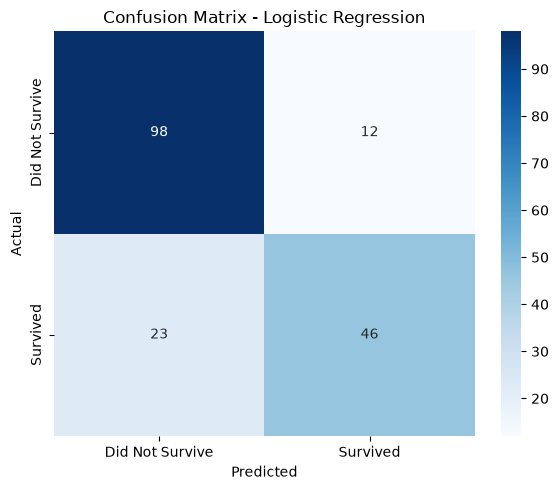

In [9]:
# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Did Not Survive', 'Survived'],
    yticklabels=['Did Not Survive', 'Survived']
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()

plt.savefig('../visualizations/confusion_matrix.png', dpi=300)
plt.show()

ROC-AUC Score: 0.8443


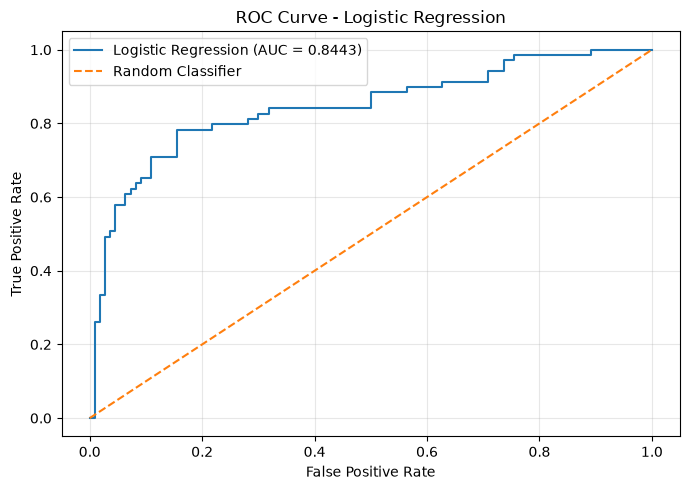

In [10]:
# Generate ROC Curve and calculate AUC

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {auc_score:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')

plt.title('ROC Curve - Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('../visualizations/roc_curve.png', dpi=300)
plt.show()

In [11]:
# Detailed Classification Report

print("CLASSIFICATION REPORT")
print("=" * 50)

print(classification_report(
    y_test,
    y_pred,
    target_names=['Did Not Survive', 'Survived']
))

CLASSIFICATION REPORT
                 precision    recall  f1-score   support

Did Not Survive       0.81      0.89      0.85       110
       Survived       0.79      0.67      0.72        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



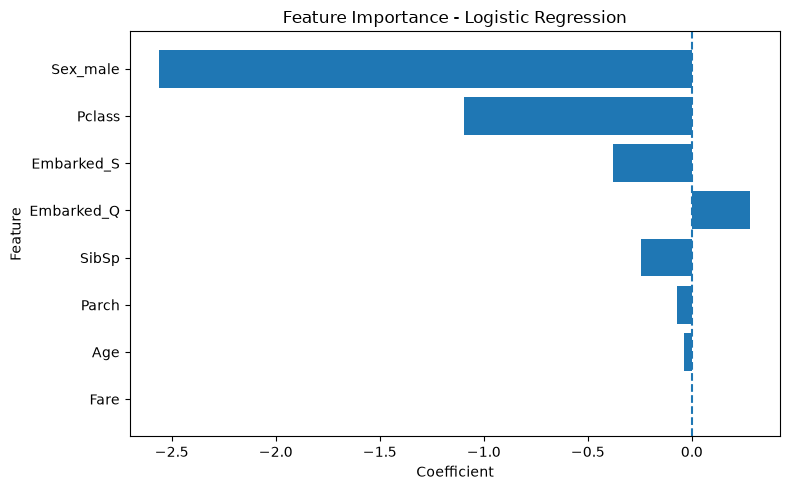

      Feature  Coefficient
4        Fare     0.002235
1         Age    -0.038557
3       Parch    -0.071070
2       SibSp    -0.244426
6  Embarked_Q     0.281753
7  Embarked_S    -0.380264
0      Pclass    -1.093124
5    Sex_male    -2.559795


In [12]:
# Visualize Logistic Regression Feature Coefficients

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

feature_importance['Absolute_Importance'] = (
    feature_importance['Coefficient'].abs()
)

feature_importance = feature_importance.sort_values(
    'Absolute_Importance',
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Coefficient']
)

plt.axvline(0, linestyle='--')

plt.title('Feature Importance - Logistic Regression')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.tight_layout()

plt.savefig('../visualizations/feature_importance.png', dpi=300)
plt.show()

print(feature_importance[['Feature', 'Coefficient']])

In [13]:
# Save model evaluation results

results = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score',
        'ROC-AUC'
    ],
    'Value': [
        accuracy,
        precision,
        recall,
        f1,
        auc_score
    ]
})

results.to_csv('../report/model_evaluation_results.csv', index=False)

print("Model evaluation results saved successfully!")
display(results)

Model evaluation results saved successfully!


,Metric,Value
0,Accuracy,0.804469
1,Precision,0.793103
2,Recall,0.666667
3,F1-Score,0.724409
4,ROC-AUC,0.844269
